<a href="https://colab.research.google.com/github/chadnar2/stockprediction/blob/main/mergedstockanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance pandas numpy scikit-learn tensorflow vaderSentiment beautifulsoup4 lxml

In [ ]:

import numpy as np
import pandas as pd
import yfinance as yf
import requests

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
#Ask for the stock in question
ticker = input("Please the stock symbol to predict for the next 30 days: ")

# -----------------------------
# 1) Scrape news headlines
# -----------------------------
def get_finviz_news(ticker):
    url = f"https://finviz.com/quote.ashx?t={ticker}"
    headers = {"User-Agent": "Mozilla/5.0"}
    html = requests.get(url, headers=headers, timeout=20).text
    soup = BeautifulSoup(html, "html.parser")

    # Finviz news table contains date/time and headline rows
    tables = pd.read_html(str(soup))
    news_table = None
    for t in tables:
        if t.shape[1] == 2:
            news_table = t
            break

    if news_table is None:
        raise ValueError("Could not find news table on page.")

    news_table.columns = ["DateTime", "Headline"]
    return news_table

# -----------------------------
# 2) Sentiment analysis
# -----------------------------
def add_sentiment(news_df):
    analyzer = SentimentIntensityAnalyzer()
    news_df = news_df.copy()
    news_df["sentiment"] = news_df["Headline"].astype(str).apply(
        lambda x: analyzer.polarity_scores(x)["compound"]
    )
    return news_df

# -----------------------------
# 3) Aggregate by date
# -----------------------------
def daily_sentiment(news_df):
    df = news_df.copy()

    # Finviz may return date+time or just time on some rows; keep only rows with a date
    df["Date"] = pd.to_datetime(df["DateTime"], errors="coerce").dt.date
    df = df.dropna(subset=["Date"])

    daily = df.groupby("Date").agg(
        sentiment_mean=("sentiment", "mean"),
        sentiment_count=("sentiment", "count")
    ).reset_index()

    daily["Date"] = pd.to_datetime(daily["Date"])
    return daily

# -----------------------------
# 4) Get price data
# -----------------------------

prices = yf.download(ticker, period="2y", auto_adjust=False)
prices = prices.reset_index()

# Flatten column names from yfinance output (MultiIndex to single-level strings)
new_columns = []
for col in prices.columns:
    if isinstance(col, tuple):
        # For tuples like ('Date', ''), we want 'Date' (col[0])
        # For tuples like ('Close', 'AMD'), we want 'Close' (col[0])
        new_columns.append(col[0])
    else:
        new_columns.append(col)
prices.columns = new_columns

prices = prices[["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]]

# -----------------------------
# 5) Scrape + sentiment
# -----------------------------
news = get_finviz_news(ticker)
news = add_sentiment(news)
sent_daily = daily_sentiment(news)

# -----------------------------
# 6) Merge price + sentiment
# -----------------------------
data = prices.merge(sent_daily, on="Date", how="left")
data["sentiment_mean"] = data["sentiment_mean"].fillna(0.0)
data["sentiment_count"] = data["sentiment_count"].fillna(0)

# Optional: create one-step-ahead target
data["Target"] = data["Close"].shift(-1)
data = data.dropna().reset_index(drop=True)

# -----------------------------
# 7) Feature scaling
# -----------------------------
feature_cols = [
    "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "sentiment_mean", "sentiment_count"
]

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(data[feature_cols])

target_scaler = MinMaxScaler()
scaled_target = target_scaler.fit_transform(data[["Target"]])

# -----------------------------
# 8) Build sequences
# -----------------------------
lookback = 60
X, y = [], []

for i in range(lookback, len(data)):
    X.append(scaled_features[i - lookback:i, :])
    y.append(scaled_target[i, 0])

X = np.array(X)
y = np.array(y)

# -----------------------------
# 9) Train/test split
# -----------------------------
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# 10) Build LSTM
# -----------------------------
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)

print("Model trained successfully!")

# -----------------------------
# 11) Predict and invert scale
# -----------------------------
pred_scaled = model.predict(X_test)
pred_price = target_scaler.inverse_transform(pred_scaled)
actual_price = target_scaler.inverse_transform(y_test.reshape(-1, 1))
print("Number of predicted rows : ", len(pred_price))
print("Predicted:", pred_price[79:].flatten())
print("Actual:   ", actual_price[79:].flatten())

Please the stock symbol to predict for the next 30 days: INTC


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_462/36312012.py:24: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(str(soup))
/tmp/ipykernel_462/36312012.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["DateTime"], errors="coerce").dt.date
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 338ms/step - loss: 0.0032 - val_loss: 0.0573
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 9.9110e-04 - val_loss: 0.0391
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 6.4113e-04 - val_loss: 0.0210
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 5.3811e-04 - val_loss: 0.0352
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 4.3673e-04 - val_loss: 0.0292
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 4.0617e-04 - val_loss: 0.0311
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 4.1762e-04 - val_loss: 0.0336
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 3.9464e-04 - val_loss: 0.0331
Model trained successfully!
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step
Number of predicted rows :  89
Predicted: [108.4026   108.78805  109.04344  109.01228  108.76522  108.14751
 107.40823  106.497116 105.48132  104.45805 ]
Actual:    [120.34999847 122.19999695 110.38999939 110.23999786 11

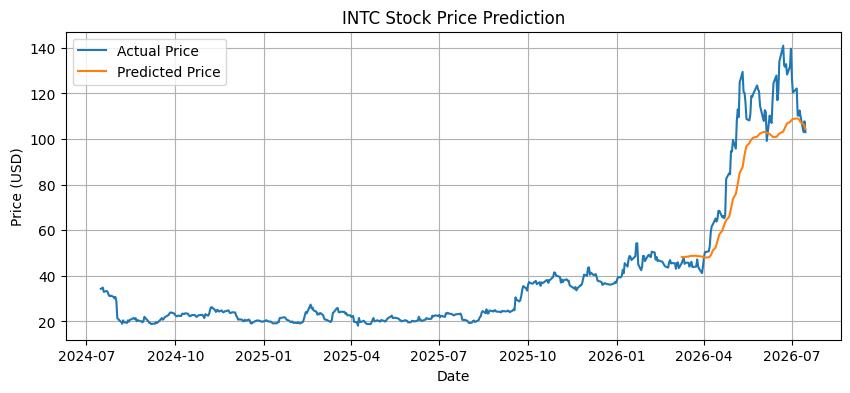

In [ ]:
#Plot the graph
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(data["Date"], data["Close"], label="Actual Price")
plt.plot(data["Date"][-len(pred_price):], pred_price, label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title(f"{ticker} Stock Price Prediction")
plt.legend()
plt.grid(True)
plt.show()
#orange predicted, blue actual price

In [ ]:
print(data.tail()[["Date","Close","Adj Close","Target"]])

          Date       Close   Adj Close      Target
496 2026-07-09  112.540001  112.540001  109.839996
497 2026-07-10  109.839996  109.839996  103.120003
498 2026-07-13  103.120003  103.120003  107.760002
499 2026-07-14  107.760002  107.760002  102.989998
500 2026-07-15  102.989998  102.989998   96.519997


In [ ]:

hist = yf.download(ticker, period="2y", auto_adjust=False)
print(hist.tail()[["Close", "Adj Close"]])

[*********************100%***********************]  1 of 1 completed

Price            Close   Adj Close
Ticker            INTC        INTC
Date                              
2026-07-10  109.839996  109.839996
2026-07-13  103.120003  103.120003
2026-07-14  107.760002  107.760002
2026-07-15  102.989998  102.989998
2026-07-16   96.400002   96.400002


In [ ]:
# Take the last 60 days from your features
last_60 = scaled_features[-60:, :].reshape(1, 60, scaled_features.shape[1])

next_scaled = model.predict(last_60)                # shape (1, 1)
next_adj_close = target_scaler.inverse_transform(next_scaled)[0, 0]

print("Model forecast (adjusted close):", next_adj_close)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Model forecast (adjusted close): 103.49974


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 967ms/step - loss: 0.8867 - val_loss: 1.6202
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 511ms/step - loss: 0.8859 - val_loss: 1.6205
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - loss: 0.8852 - val_loss: 1.6208
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - loss: 0.8845 - val_loss: 1.6222
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - loss: 0.8834 - val_loss: 1.6230
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 274ms/step - loss: 0.8824 - val_loss: 1.6252
Model trained successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
Current price: 96.45780181884766
Predicted 60-day price path:
Day  1: $96.72
Day  2: $97.02
Day  3: $97.35
Day  4: $97.71
Day  5: $98.03
Day  6: $98.34
Day  7: $98.88
Day  8: $99.40
Day  9: $99.70
Day 10: $100.26
Day 11: $100.74
Day 12: $100.97
Day 13: $101.25
Day 14: $101.55
Day 15: $102.08
Day 16: $102.51
Day 17: $102.69
Day 18: $103.04
Day 19: $103.27
Day 20: $103.40
Day 21: $103.63
Day 22: $104.06
Day 23: $104.36
Day 24:

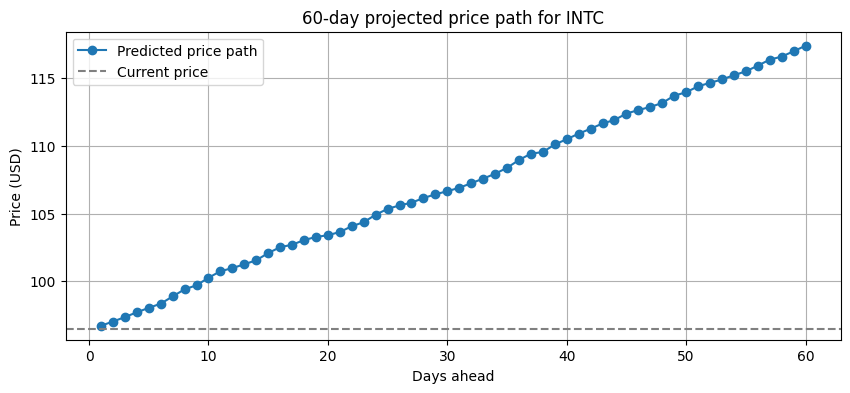

In [ ]:
# pip install yfinance pandas numpy scikit-learn tensorflow

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# 1) Load data
# -----------------------------

data = yf.download(ticker, period="2y", auto_adjust=False)
data = data.reset_index()

# Flatten column names if needed (yfinance can return MultiIndex)
new_cols = []
for col in data.columns:
    if isinstance(col, tuple):
        new_cols.append(col[0])
    else:
        new_cols.append(col)
data.columns = new_cols

data = data[["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]]

# -----------------------------
# 2) Compute daily returns (on Close)
# -----------------------------
# Using simple returns: r_t = (Close_t / Close_{t-1}) - 1
data["Return"] = data["Close"].pct_change()
data = data.dropna().reset_index(drop=True)

# Keep returns as a 2D array for scaling
ret_arr = data[["Return"]].values  # shape (N, 1)

# -----------------------------
# 3) Scale returns
# -----------------------------
ret_scaler = StandardScaler()
scaled_ret = ret_scaler.fit_transform(ret_arr)  # (N, 1)

# -----------------------------
# 4) Build multi-step sequences
# -----------------------------
lookback = 120   # use past 120 days of returns
horizon  = 60   # predict next 60 days of returns

X, y = [], []

for i in range(lookback, len(data) - horizon):
    # past 60 returns
    X.append(scaled_ret[i - lookback:i, :])          # shape (120, 1)
    # next 30 returns
    y.append(scaled_ret[i:i + horizon, :].ravel())   # shape (60,)

X = np.array(X)  # (samples, 120, 1)
y = np.array(y)  # (samples, 60)

# -----------------------------
# 5) Train/test split
# -----------------------------
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# 6) Build LSTM (multi-output: 30 returns)
# -----------------------------
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, X_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dense(32, activation="relu"),
    Dense(horizon)  # 30 outputs
])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

print("Model trained successfully!")

# -----------------------------
# 7) Predict next 60 days of returns from today
# -----------------------------
# Last 120 days of returns
last_120_ret = ret_arr[-lookback:, :]                 # (120, 1)
last_120_ret_scaled = ret_scaler.transform(last_120_ret)  # (120, 1)

# Model expects shape (1, 60, 1)
last_120_ret_scaled = last_120_ret_scaled.reshape(1, lookback, X_train.shape[2])

future_returns_scaled = model.predict(last_120_ret_scaled)  # (1, 30)

# Inverse scale to raw returns
future_returns = ret_scaler.inverse_transform(
    future_returns_scaled.reshape(-1, 1)
).reshape(-1)  # length 30

# -----------------------------
# 8) Compound returns into a price path
# -----------------------------
current_price = data["Close"].iloc[-1]  # latest actual close

price_path = []
price = current_price

for r in future_returns:
    price = price * (1 + r)
    price_path.append(price)

# -----------------------------
# 9) Show results
# -----------------------------
print("Current price:", current_price)
print("Predicted 60-day price path:")
for i, p in enumerate(price_path, start=1):
    print(f"Day {i:2d}: ${p:.2f}")

# Optional: quick plot
import matplotlib.pyplot as plt

days = list(range(1, horizon + 1))
plt.figure(figsize=(10, 4))
plt.plot(days, price_path, marker="o", label="Predicted price path")
plt.axhline(current_price, color="gray", linestyle="--", label="Current price")
plt.xlabel("Days ahead")
plt.ylabel("Price (USD)")
plt.title(f"60-day projected price path for {ticker}")
plt.legend()
plt.grid(True)
plt.show()